In [0]:
## Churn Prediction

In [0]:
# Connecting Snowflake Database
sfOptions = {
 "sfURL" : "PTYUFYW-TS33125.snowflakecomputing.com",
 "sfUser" : "PASUPULASUNIL8",
 "sfPassword" : "Sunil@8374629730",
 "sfDatabase" : "TELECOM",
 "sfSchema" : "PUBLIC",
 "sfWarehouse" : "COMPUTE_WH"
}

In [0]:
## Data Table And structure
df = spark.read \
  .format("snowflake") \
  .options(**sfOptions) \
  .option("dbtable", "CUSTOMER_CHURN") \
  .load()

df.show()

+----------+------+-------------+-------+----------+------+------------+----------------+---------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------------+----------------+--------------------+--------------+------------+-----+
|CUSTOMERID|GENDER|SENIORCITIZEN|PARTNER|DEPENDENTS|TENURE|PHONESERVICE|   MULTIPLELINES|INTERNETSERVICE|     ONLINESECURITY|       ONLINEBACKUP|   DEVICEPROTECTION|        TECHSUPPORT|        STREAMINGTV|    STREAMINGMOVIES|      CONTRACT|PAPERLESSBILLING|       PAYMENTMETHOD|MONTHLYCHARGES|TOTALCHARGES|CHURN|
+----------+------+-------------+-------+----------+------+------------+----------------+---------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------------+----------------+--------------------+--------------+------------+-----+
|7590-VHVEG|Female|            0|    Yes|        No|     1|  

In [0]:
# Data Schema
df.printSchema()

root
 |-- CUSTOMERID: string (nullable = true)
 |-- GENDER: string (nullable = true)
 |-- SENIORCITIZEN: decimal(38,0) (nullable = true)
 |-- PARTNER: string (nullable = true)
 |-- DEPENDENTS: string (nullable = true)
 |-- TENURE: decimal(38,0) (nullable = true)
 |-- PHONESERVICE: string (nullable = true)
 |-- MULTIPLELINES: string (nullable = true)
 |-- INTERNETSERVICE: string (nullable = true)
 |-- ONLINESECURITY: string (nullable = true)
 |-- ONLINEBACKUP: string (nullable = true)
 |-- DEVICEPROTECTION: string (nullable = true)
 |-- TECHSUPPORT: string (nullable = true)
 |-- STREAMINGTV: string (nullable = true)
 |-- STREAMINGMOVIES: string (nullable = true)
 |-- CONTRACT: string (nullable = true)
 |-- PAPERLESSBILLING: string (nullable = true)
 |-- PAYMENTMETHOD: string (nullable = true)
 |-- MONTHLYCHARGES: double (nullable = true)
 |-- TOTALCHARGES: string (nullable = true)
 |-- CHURN: string (nullable = true)



In [0]:
# Verifying Total Records
df.count()

7043

In [0]:
# Importing Neccessary Packages
from pyspark.sql.functions import when, col, sum

In [0]:
df = df.withColumn(
    "Churn",
    when(col("Churn") == "Yes", 1).otherwise(0)
)

In [0]:
df.show(10)

+----------+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+--------------+------------+-----+
|CUSTOMERID|GENDER|SENIORCITIZEN|PARTNER|DEPENDENTS|TENURE|PHONESERVICE|   MULTIPLELINES|INTERNETSERVICE|ONLINESECURITY|ONLINEBACKUP|DEVICEPROTECTION|TECHSUPPORT|STREAMINGTV|STREAMINGMOVIES|      CONTRACT|PAPERLESSBILLING|       PAYMENTMETHOD|MONTHLYCHARGES|TOTALCHARGES|Churn|
+----------+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+--------------+------------+-----+
|7590-VHVEG|Female|            0|    Yes|        No|     1|          No|No phone service|            DSL|            No|         Yes|              No|         No|    

In [0]:

# Checking Missing Values
missing_values = df.select([
    sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
])

transpose_df = missing_values.selectExpr(
    "stack({}, {}) as (column_name, missing_count)".format(
        len(df.columns),
        ",".join(["'{}', {}".format(c, c) for c in df.columns])
    )
)

transpose_df.show()

+----------------+-------------+
|     column_name|missing_count|
+----------------+-------------+
|      CUSTOMERID|            0|
|          GENDER|            0|
|   SENIORCITIZEN|            0|
|         PARTNER|            0|
|      DEPENDENTS|            0|
|          TENURE|            0|
|    PHONESERVICE|            0|
|   MULTIPLELINES|            0|
| INTERNETSERVICE|            0|
|  ONLINESECURITY|            0|
|    ONLINEBACKUP|            0|
|DEVICEPROTECTION|            0|
|     TECHSUPPORT|            0|
|     STREAMINGTV|            0|
| STREAMINGMOVIES|            0|
|        CONTRACT|            0|
|PAPERLESSBILLING|            0|
|   PAYMENTMETHOD|            0|
|  MONTHLYCHARGES|            0|
|    TOTALCHARGES|           11|
+----------------+-------------+
only showing top 20 rows


In [0]:
for c in df.columns[1:]:
    print(f"Value counts for {c}")
    df.groupBy(c).count().show()

Value counts for GENDER
+------+-----+
|GENDER|count|
+------+-----+
|Female| 3488|
|  Male| 3555|
+------+-----+

Value counts for SENIORCITIZEN
+-------------+-----+
|SENIORCITIZEN|count|
+-------------+-----+
|            1| 1142|
|            0| 5901|
+-------------+-----+

Value counts for PARTNER
+-------+-----+
|PARTNER|count|
+-------+-----+
|    Yes| 3402|
|     No| 3641|
+-------+-----+

Value counts for DEPENDENTS
+----------+-----+
|DEPENDENTS|count|
+----------+-----+
|       Yes| 2110|
|        No| 4933|
+----------+-----+

Value counts for TENURE
+------+-----+
|TENURE|count|
+------+-----+
|    10|  116|
|    48|   64|
|    11|   99|
|    44|   51|
|    62|   70|
|     7|  131|
|    26|   79|
|    50|   68|
|     6|  110|
|    60|   76|
|    31|   65|
|    28|   57|
|    17|   87|
|    57|   65|
|    27|   72|
|    15|   99|
|    23|   85|
|    54|   68|
|    12|  117|
|     4|  176|
+------+-----+
only showing top 20 rows
Value counts for PHONESERVICE
+------------+---

In [0]:
df = df.withColumn(
    "GENDER",
    when(col("GENDER") == "Male", 1).otherwise(0)
)

In [0]:
# Replacing Binary Values into 0 and 1 respectively
binary_columns = [
"Partner",
"Dependents",
"PhoneService",
"PaperlessBilling"
]

for c in binary_columns:
    df = df.withColumn(
        c,
        when(col(c) == "Yes", 1).otherwise(0)
    )

In [0]:

# Replacing Yes, No values as 1,0 respectively
columns = [
"MULTIPLELINES",
"ONLINESECURITY",
"ONLINEBACKUP",
"DEVICEPROTECTION",
"TECHSUPPORT",
"STREAMINGTV",
"STREAMINGMOVIES"
]

for c in columns:
    if c == 'MULTIPLELINES':
        df = df.withColumn(
            c,
            when(col(c) == "Yes", 1)
            .when(col(c) == "No", 0)
            .when(col(c) == "No phone service", 0)
        )
    else:
        df = df.withColumn(
        c,
        when(col(c) == "Yes", 1)
        .when(col(c) == "No", 0)
        .when(col(c) == "No internet service", 0)
    )

In [0]:
 # column wise count of Values
for c in df.columns[1:]:
    print(f"Value counts for {c}")
    df.groupBy(c).count().show()

Value counts for GENDER
+------+-----+
|GENDER|count|
+------+-----+
|     1| 3555|
|     0| 3488|
+------+-----+

Value counts for SENIORCITIZEN
+-------------+-----+
|SENIORCITIZEN|count|
+-------------+-----+
|            1| 1142|
|            0| 5901|
+-------------+-----+

Value counts for Partner
+-------+-----+
|Partner|count|
+-------+-----+
|      1| 3402|
|      0| 3641|
+-------+-----+

Value counts for Dependents
+----------+-----+
|Dependents|count|
+----------+-----+
|         1| 2110|
|         0| 4933|
+----------+-----+

Value counts for TENURE
+------+-----+
|TENURE|count|
+------+-----+
|    10|  116|
|    48|   64|
|    11|   99|
|    44|   51|
|    62|   70|
|     7|  131|
|    26|   79|
|    50|   68|
|     6|  110|
|    60|   76|
|    31|   65|
|    28|   57|
|    17|   87|
|    57|   65|
|    27|   72|
|    15|   99|
|    23|   85|
|    54|   68|
|    12|  117|
|     4|  176|
+------+-----+
only showing top 20 rows
Value counts for PhoneService
+------------+---

In [0]:
# Label Encoding

In [0]:

 # Encoding Internet Service
df = df.withColumn(
    "PAYMENTMETHOD",
    when(col("PAYMENTMETHOD") == "Electronic check", "Electronic")
    .when(col("PAYMENTMETHOD") == "Mailed check", "Mail")
    .when(col("PAYMENTMETHOD") == "Credit card (automatic)", "CreditCard")
    .when(col("PAYMENTMETHOD") == "Bank transfer (automatic)", "BankTransfer")
)

In [0]:
 # Importing Necessary Libraries for Label Encoding
from pyspark.ml.feature import StringIndexer, OneHotEncoder

In [0]:
internet_indexer = StringIndexer(inputCol="INTERNETSERVICE", outputCol="INTERNETSERVICE_index")

contract_indexer = StringIndexer(inputCol="CONTRACT", outputCol="CONTRACT_index")

payment_indexer = StringIndexer(inputCol="PAYMENTMETHOD", outputCol="PAYMENTMETHOD_index")

In [0]:
encoder = OneHotEncoder(
    inputCols=[
        "INTERNETSERVICE_index",
        "CONTRACT_index",
        "PAYMENTMETHOD_index"
    ],
    outputCols=[
        "INTERNETSERVICE_vec",
        "CONTRACT_vec",
        "PAYMENTMETHOD_vec"
    ]
)

In [0]:
# Pipeline for Encoding Columns
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=[
    internet_indexer,
    contract_indexer,
    payment_indexer,
    encoder
])

df = pipeline.fit(df).transform(df)

In [0]:
# Dropping Columns 
df = df.drop(
    "INTERNETSERVICE",
    "CONTRACT",
    "PAYMENTMETHOD",
    "INTERNETSERVICE_index",
    "CONTRACT_index",
    "PAYMENTMETHOD_index"
)

In [0]:
 # Filling Missing Values with Mean Value
df = df.withColumn(
    "TOTALCHARGES",
    when(col("TOTALCHARGES") == " ", None).otherwise(col("TOTALCHARGES"))
)

In [0]:
df = df.withColumn(
    "TOTALCHARGES",
    col("TOTALCHARGES").cast("double")
)

In [0]:
from pyspark.sql.functions import mean

mean_total = df.select(mean("TOTALCHARGES")).collect()[0][0]

In [0]:
df = df.fillna({
    "TOTALCHARGES": mean_total
})

In [0]:
# Checking for Missing Values
df.select("TOTALCHARGES").where(col("TOTALCHARGES").isNull()).count()

0

In [0]:
 # Dropping CustomerID
df = df.drop("CUSTOMERID")

In [0]:
# Coverting Data Types for the Tenure Column
df = df.withColumn(
    "TENURE",
    col("TENURE").cast("int")
)

In [0]:
# Checking Data Types
df.printSchema()

root
 |-- GENDER: integer (nullable = false)
 |-- SENIORCITIZEN: decimal(38,0) (nullable = true)
 |-- Partner: integer (nullable = false)
 |-- Dependents: integer (nullable = false)
 |-- TENURE: integer (nullable = true)
 |-- PhoneService: integer (nullable = false)
 |-- MULTIPLELINES: integer (nullable = true)
 |-- ONLINESECURITY: integer (nullable = true)
 |-- ONLINEBACKUP: integer (nullable = true)
 |-- DEVICEPROTECTION: integer (nullable = true)
 |-- TECHSUPPORT: integer (nullable = true)
 |-- STREAMINGTV: integer (nullable = true)
 |-- STREAMINGMOVIES: integer (nullable = true)
 |-- PaperlessBilling: integer (nullable = false)
 |-- MONTHLYCHARGES: double (nullable = true)
 |-- TOTALCHARGES: double (nullable = false)
 |-- Churn: integer (nullable = false)
 |-- INTERNETSERVICE_vec: vectorudt (nullable = true)
 |-- CONTRACT_vec: vectorudt (nullable = true)
 |-- PAYMENTMETHOD_vec: vectorudt (nullable = true)



In [0]:
# Data Summary
desc = df.describe()
desc.show()

+-------+------------------+------------------+------------------+------------------+-----------------+------------------+-------------------+-------------------+------------------+-------------------+------------------+-------------------+------------------+------------------+-----------------+------------------+-------------------+
|summary|            GENDER|     SENIORCITIZEN|           Partner|        Dependents|           TENURE|      PhoneService|      MULTIPLELINES|     ONLINESECURITY|      ONLINEBACKUP|   DEVICEPROTECTION|       TECHSUPPORT|        STREAMINGTV|   STREAMINGMOVIES|  PaperlessBilling|   MONTHLYCHARGES|      TOTALCHARGES|              Churn|
+-------+------------------+------------------+------------------+------------------+-----------------+------------------+-------------------+-------------------+------------------+-------------------+------------------+-------------------+------------------+------------------+-----------------+------------------+-------------

In [0]:
# Basic Stats for the features
from pyspark.sql.functions import expr

cols = desc.columns[1:]

stack_expr = "stack({}, {}) as (feature, value)".format(
    len(cols),
    ",".join([f"'{c}', `{c}`" for c in cols])
)

transpose_desc = desc.selectExpr("summary", stack_expr)

transpose_desc.show()

+-------+-------------+------------------+
|summary|      feature|             value|
+-------+-------------+------------------+
|  count|       GENDER|              7043|
|   mean|       GENDER| 0.504756495811444|
| stddev|       GENDER|0.5000128736471502|
|    min|       GENDER|                 0|
|    max|       GENDER|                 1|
|  count|SENIORCITIZEN|              7043|
|   mean|SENIORCITIZEN|            0.1621|
| stddev|SENIORCITIZEN|0.3686116056100118|
|    min|SENIORCITIZEN|                 0|
|    max|SENIORCITIZEN|                 1|
|  count|      Partner|              7043|
|   mean|      Partner|0.4830327985233565|
| stddev|      Partner|0.4997475107199892|
|    min|      Partner|                 0|
|    max|      Partner|                 1|
|  count|   Dependents|              7043|
|   mean|   Dependents|0.2995882436461735|
| stddev|   Dependents|0.4581101675100146|
|    min|   Dependents|                 0|
|    max|   Dependents|                 1|
+-------+--

In [0]:
# Column wise Missing Values
missing_values = df.select([
    sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
])

transpose_df = missing_values.selectExpr(
    "stack({}, {}) as (column_name, missing_count)".format(
        len(df.columns),
        ",".join(["'{}', {}".format(c, c) for c in df.columns])
    )
)

transpose_df.show()

+-------------------+-------------+
|        column_name|missing_count|
+-------------------+-------------+
|             GENDER|            0|
|      SENIORCITIZEN|            0|
|            Partner|            0|
|         Dependents|            0|
|             TENURE|            0|
|       PhoneService|            0|
|      MULTIPLELINES|            0|
|     ONLINESECURITY|            0|
|       ONLINEBACKUP|            0|
|   DEVICEPROTECTION|            0|
|        TECHSUPPORT|            0|
|        STREAMINGTV|            0|
|    STREAMINGMOVIES|            0|
|   PaperlessBilling|            0|
|     MONTHLYCHARGES|            0|
|       TOTALCHARGES|            0|
|              Churn|            0|
|INTERNETSERVICE_vec|            0|
|       CONTRACT_vec|            0|
|  PAYMENTMETHOD_vec|            0|
+-------------------+-------------+



In [0]:
# Additing New Features
# ======================================
# 1. Average Monthly Spend
# 2. Total Services Used
# 3. Customer Tenure Group
# 4. High Monthly Charges Flag

In [0]:
# Average Monthly Spend Feature

df = df.withColumn(
    "avg_monthly_spend",
    col("TOTALCHARGES") / (col("TENURE") + 1)
)

In [0]:
# Total Services Used
df = df.withColumn(
    "total_services",
    col("PhoneService") +
    col("MULTIPLELINES") +
    col("ONLINESECURITY") +
    col("ONLINEBACKUP") +
    col("DEVICEPROTECTION") +
    col("TECHSUPPORT") +
    col("STREAMINGTV") +
    col("STREAMINGMOVIES")
)


In [0]:
# Customer Tenure Group

df = df.withColumn(
    "tenure_group",
    when(col("TENURE") < 12, 0)
    .when((col("TENURE") >= 12) & (col("TENURE") < 24), 1)
    .when((col("TENURE") >= 24) & (col("TENURE") < 48), 2)
    .otherwise(3)
)

In [0]:
# High Monthly Charges Flag
df = df.withColumn(
    "high_charges_flag",
    when(col("MONTHLYCHARGES") > 80, 1).otherwise(0)
)

In [0]:
df.select('GENDER',
 'SENIORCITIZEN',
 'Partner',
 'Dependents',
 'TENURE',
 'PhoneService',
 'MULTIPLELINES',
 'ONLINESECURITY',
 'ONLINEBACKUP',
 'DEVICEPROTECTION').show(10)

+------+-------------+-------+----------+------+------------+-------------+--------------+------------+----------------+
|GENDER|SENIORCITIZEN|Partner|Dependents|TENURE|PhoneService|MULTIPLELINES|ONLINESECURITY|ONLINEBACKUP|DEVICEPROTECTION|
+------+-------------+-------+----------+------+------------+-------------+--------------+------------+----------------+
|     0|            0|      1|         0|     1|           0|            0|             0|           1|               0|
|     1|            0|      0|         0|    34|           1|            0|             1|           0|               1|
|     1|            0|      0|         0|     2|           1|            0|             1|           1|               0|
|     1|            0|      0|         0|    45|           0|            0|             1|           0|               1|
|     0|            0|      0|         0|     2|           1|            0|             0|           0|               0|
|     0|            0|      0|  

In [0]:
df.select ('TECHSUPPORT',
 'STREAMINGTV',
 'STREAMINGMOVIES',
 'PaperlessBilling',
 'MONTHLYCHARGES',
 'TOTALCHARGES',
 'Churn').show(10)

+-----------+-----------+---------------+----------------+--------------+------------+-----+
|TECHSUPPORT|STREAMINGTV|STREAMINGMOVIES|PaperlessBilling|MONTHLYCHARGES|TOTALCHARGES|Churn|
+-----------+-----------+---------------+----------------+--------------+------------+-----+
|          0|          0|              0|               1|         29.85|       29.85|    0|
|          0|          0|              0|               0|         56.95|      1889.5|    0|
|          0|          0|              0|               1|         53.85|      108.15|    1|
|          1|          0|              0|               0|          42.3|     1840.75|    0|
|          0|          0|              0|               1|          70.7|      151.65|    1|
|          0|          1|              1|               1|         99.65|       820.5|    1|
|          0|          1|              0|               1|          89.1|      1949.4|    0|
|          0|          0|              0|               0|         29.

In [0]:
# Checking Updated Columns
df.select(
'INTERNETSERVICE_vec',
 'CONTRACT_vec',
 'PAYMENTMETHOD_vec',
 'avg_monthly_spend',
 'total_services',
 'tenure_group',
 'high_charges_flag'
).show(5)

+-------------------+-------------+-----------------+------------------+--------------+------------+-----------------+
|INTERNETSERVICE_vec| CONTRACT_vec|PAYMENTMETHOD_vec| avg_monthly_spend|total_services|tenure_group|high_charges_flag|
+-------------------+-------------+-----------------+------------------+--------------+------------+-----------------+
|      (2,[1],[1.0])|(2,[0],[1.0])|    (3,[0],[1.0])|            14.925|             1|           0|                0|
|      (2,[1],[1.0])|    (2,[],[])|    (3,[1],[1.0])| 53.98571428571429|             3|           2|                0|
|      (2,[1],[1.0])|(2,[0],[1.0])|    (3,[1],[1.0])|36.050000000000004|             3|           0|                0|
|      (2,[1],[1.0])|    (2,[],[])|    (3,[2],[1.0])|40.016304347826086|             3|           2|                0|
|      (2,[0],[1.0])|(2,[0],[1.0])|    (3,[0],[1.0])|50.550000000000004|             1|           0|                0|
+-------------------+-------------+-------------

['GENDER',
 'SENIORCITIZEN',
 'Partner',
 'Dependents',
 'TENURE',
 'PhoneService',
 'MULTIPLELINES',
 'ONLINESECURITY',
 'ONLINEBACKUP',
 'DEVICEPROTECTION',
 'TECHSUPPORT',
 'STREAMINGTV',
 'STREAMINGMOVIES',
 'PaperlessBilling',
 'MONTHLYCHARGES',
 'TOTALCHARGES',
 'Churn',
 'INTERNETSERVICE_vec',
 'CONTRACT_vec',
 'PAYMENTMETHOD_vec',
 'avg_monthly_spend',
 'total_services',
 'tenure_group',
 'high_charges_flag']

In [0]:
# Creating Feature Vectors
from pyspark.ml.feature import VectorAssembler
feature_cols = [
"GENDER",
"SENIORCITIZEN",
"Partner",
"Dependents",
"TENURE",
"PhoneService",
"MULTIPLELINES",
"ONLINESECURITY",
"ONLINEBACKUP",
"DEVICEPROTECTION",
"TECHSUPPORT",
"STREAMINGTV",
"STREAMINGMOVIES",
"PaperlessBilling",
"MONTHLYCHARGES",
"TOTALCHARGES",
"avg_monthly_spend",
"total_services",
"tenure_group",
"high_charges_flag",
"INTERNETSERVICE_vec",
"CONTRACT_vec",
"PAYMENTMETHOD_vec"
]

In [0]:


binary_cols = ['GENDER','Partner','Dependents','PhoneService',
 'MULTIPLELINES','ONLINESECURITY','ONLINEBACKUP',
 'DEVICEPROTECTION','TECHSUPPORT','STREAMINGTV',
 'STREAMINGMOVIES','PaperlessBilling','high_charges_flag','Churn']

In [0]:
pdf = df.select(binary_cols).toPandas()

In [0]:
import pandas as pd
from scipy.stats import chi2_contingency
import itertools

results = []

for col1, col2 in itertools.combinations(binary_cols, 2):
    
    contingency = pd.crosstab(pdf[col1], pdf[col2])
    
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    results.append({
        "feature_1": col1,
        "feature_2": col2,
        "chi_square": chi2,
        "p_value": p
    })

chi_results = pd.DataFrame(results)

chi_results.sort_values("p_value").head(10)

,feature_1,feature_2,chi_square,p_value
86,STREAMINGMOVIES,high_charges_flag,2300.695467,0.000000e+00
53,MULTIPLELINES,high_charges_flag,1524.524707,0.000000e+00
83,STREAMINGTV,high_charges_flag,2281.762907,0.000000e+00
81,STREAMINGTV,STREAMINGMOVIES,1999.294942,0.000000e+00
13,Partner,Dependents,1441.245221,0.000000e+00
72,DEVICEPROTECTION,STREAMINGMOVIES,1137.066342,2.903000e-249
71,DEVICEPROTECTION,STREAMINGTV,1074.356205,1.237305e-235
74,DEVICEPROTECTION,high_charges_flag,1027.267073,2.125524e-225
57,ONLINESECURITY,TECHSUPPORT,885.519100,1.379821e-194
70,DEVICEPROTECTION,TECHSUPPORT,780.912722,7.621515e-172


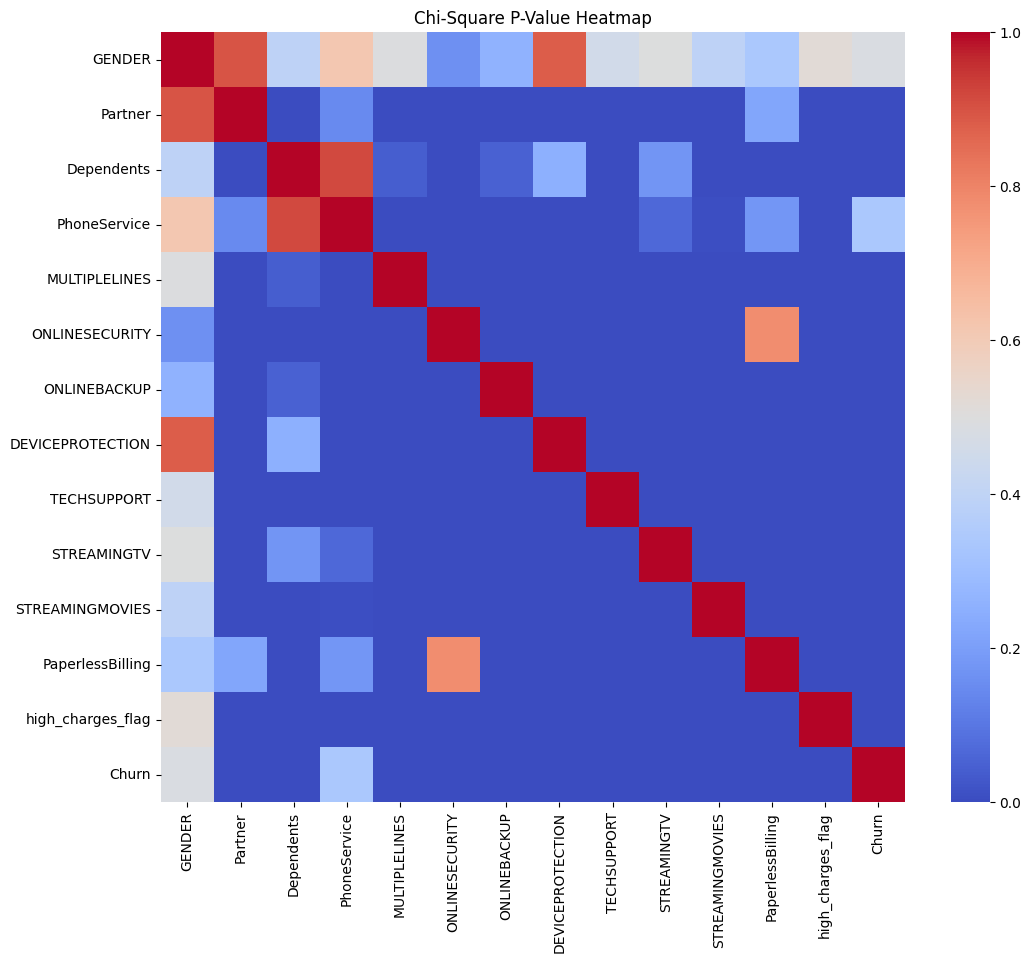

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

matrix = pd.DataFrame(index=binary_cols, columns=binary_cols)

for col1 in binary_cols:
    for col2 in binary_cols:
        
        if col1 == col2:
            matrix.loc[col1,col2] = 1
        else:
            contingency = pd.crosstab(pdf[col1], pdf[col2])
            chi2,p,_,_ = chi2_contingency(contingency)
            matrix.loc[col1,col2] = p

plt.figure(figsize=(12,10))
sns.heatmap(matrix.astype(float), cmap="coolwarm")
plt.title("Chi-Square P-Value Heatmap")
plt.show()

In [0]:
chi_results["relation"] = chi_results["p_value"].apply(
    lambda x: "Dependent" if x < 0.05 else "Independent"
)

chi_results.sort_values("p_value")

,feature_1,feature_2,chi_square,p_value,relation
86,STREAMINGMOVIES,high_charges_flag,2300.695467,0.000000,Dependent
53,MULTIPLELINES,high_charges_flag,1524.524707,0.000000,Dependent
83,STREAMINGTV,high_charges_flag,2281.762907,0.000000,Dependent
81,STREAMINGTV,STREAMINGMOVIES,1999.294942,0.000000,Dependent
13,Partner,Dependents,1441.245221,0.000000,Dependent
...,...,...,...,...,...
2,GENDER,PhoneService,0.254185,0.614143,Independent
60,ONLINESECURITY,PaperlessBilling,0.077464,0.780764,Independent
6,GENDER,DEVICEPROTECTION,0.022963,0.879553,Independent
0,GENDER,Partner,0.016356,0.898234,Independent


In [0]:
# Correlation Analsysis

pdf = df.select(
"TENURE",
"MONTHLYCHARGES",
"TOTALCHARGES",
"avg_monthly_spend",
"total_services",
"Churn"
).toPandas()

In [0]:
corr_matrix = pdf.corr()

corr_matrix

,TENURE,MONTHLYCHARGES,TOTALCHARGES,avg_monthly_spend,total_services,Churn
TENURE,1.000000,0.247900,0.824757,0.085714,0.523600,-0.352229
MONTHLYCHARGES,0.247900,1.000000,0.650468,0.284656,0.802322,0.193356
TOTALCHARGES,0.824757,0.650468,1.000000,0.250696,0.796276,-0.199428
avg_monthly_spend,0.085714,0.284656,0.250696,1.000000,0.273492,0.000817
total_services,0.523600,0.802322,0.796276,0.273492,1.000000,-0.067264
Churn,-0.352229,0.193356,-0.199428,0.000817,-0.067264,1.000000


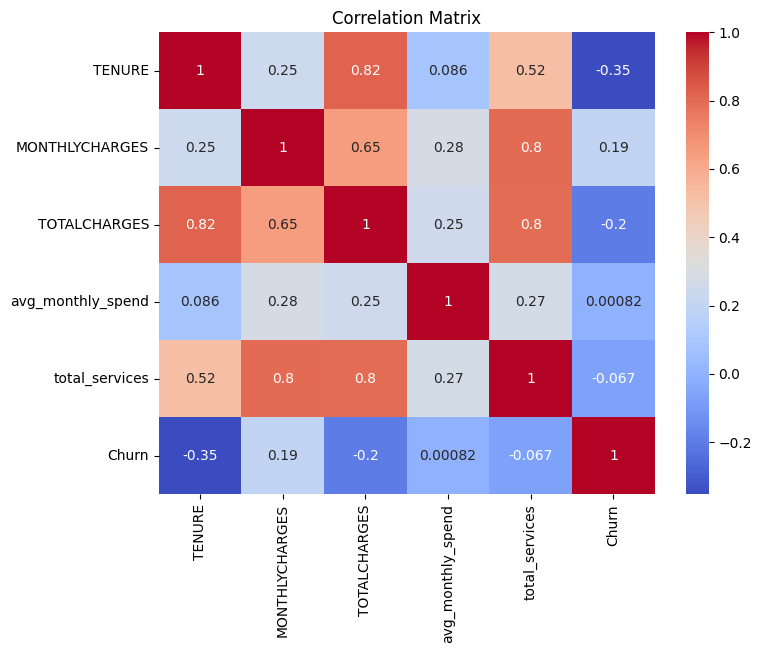

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

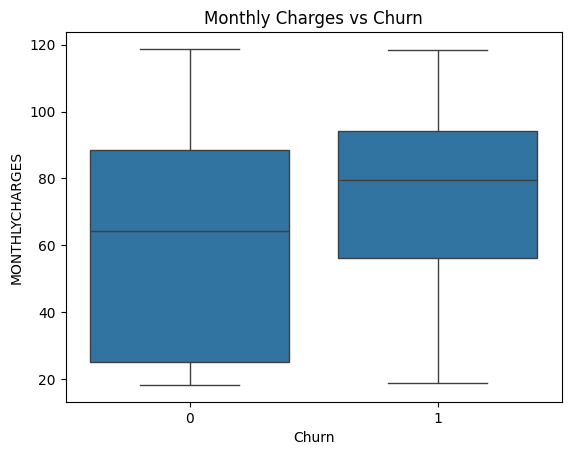

In [0]:
sns.boxplot(x="Churn", y="MONTHLYCHARGES", data=pdf)

plt.title("Monthly Charges vs Churn")
plt.show()

<Axes: xlabel='Churn', ylabel='TENURE'>

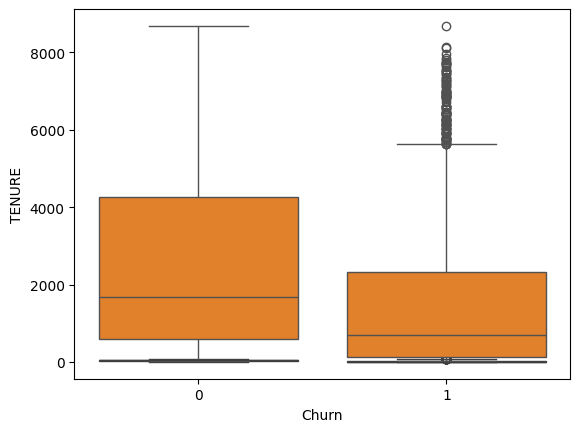

In [0]:
sns.boxplot(x="Churn", y="TENURE", data=pdf)
sns.boxplot(x="Churn", y="TOTALCHARGES", data=pdf)

In [0]:
from scipy.stats import ttest_ind

churn_yes = pdf[pdf["Churn"]==1]["MONTHLYCHARGES"]
churn_no = pdf[pdf["Churn"]==0]["MONTHLYCHARGES"]

t_stat, p_value = ttest_ind(churn_yes, churn_no)

print("t-statistic:",t_stat)
print("p-value:",p_value)

t-statistic: 16.536738015936308
p-value: 2.7066456068884154e-60


In [0]:
from scipy.stats import ttest_ind

num_cols = [
"TENURE",
"MONTHLYCHARGES",
"TOTALCHARGES",
"avg_monthly_spend",
"total_services"
]

results = []

for col in num_cols:
    
    churn_yes = pdf[pdf["Churn"]==1][col]
    churn_no = pdf[pdf["Churn"]==0][col]
    
    t,p = ttest_ind(churn_yes,churn_no)
    
    results.append({
        "feature":col,
        "t_stat":t,
        "p_value":p
    })

import pandas as pd

num_results = pd.DataFrame(results).sort_values("p_value")

num_results

,feature,t_stat,p_value
0,TENURE,-31.579551,7.999058e-205
2,TOTALCHARGES,-17.077149,4.233836e-64
1,MONTHLYCHARGES,16.536738,2.706646e-60
4,total_services,-5.656976,1.601088e-08
3,avg_monthly_spend,0.068550,9.453495e-01


In [0]:
# VectorAssembler
feature_cols = [
"GENDER",
"SENIORCITIZEN",
"Partner",
"Dependents",
"TENURE",
"PhoneService",
"MULTIPLELINES",
"ONLINESECURITY",
"ONLINEBACKUP",
"DEVICEPROTECTION",
"TECHSUPPORT",
"STREAMINGTV",
"STREAMINGMOVIES",
"PaperlessBilling",
"MONTHLYCHARGES",
"TOTALCHARGES",
"avg_monthly_spend",
"total_services",
"tenure_group",
"high_charges_flag",
"INTERNETSERVICE_vec",
"CONTRACT_vec",
"PAYMENTMETHOD_vec"
]
label_col = "Churn"

In [0]:
from pyspark.ml.feature import VectorAssembler

In [0]:
assembler = VectorAssembler(
    inputCols = feature_cols,
    outputCol = "features"
)

In [0]:
# Transforming
df_model = assembler.transform(df)

In [0]:
# Verifying Results
df_model.select("features","Churn").show(5,truncate=False)

+------------------------------------------------------------------------------------------------------------------+-----+
|features                                                                                                          |Churn|
+------------------------------------------------------------------------------------------------------------------+-----+
|(27,[2,4,8,13,14,15,16,17,21,22,24],[1.0,1.0,1.0,1.0,29.85,29.85,14.925,1.0,1.0,1.0,1.0])                         |0    |
|(27,[0,4,5,7,9,14,15,16,17,18,21,25],[1.0,34.0,1.0,1.0,1.0,56.95,1889.5,53.98571428571429,3.0,2.0,1.0,1.0])       |0    |
|(27,[0,4,5,7,8,13,14,15,16,17,21,22,25],[1.0,2.0,1.0,1.0,1.0,1.0,53.85,108.15,36.050000000000004,3.0,1.0,1.0,1.0])|1    |
|(27,[0,4,7,9,10,14,15,16,17,18,21,26],[1.0,45.0,1.0,1.0,1.0,42.3,1840.75,40.016304347826086,3.0,2.0,1.0,1.0])     |0    |
|(27,[4,5,13,14,15,16,17,20,22,24],[2.0,1.0,1.0,70.7,151.65,50.550000000000004,1.0,1.0,1.0,1.0])                   |1    |
+---------------

In [0]:
# Only Keeping Required Columns
df_final = df_model.select("features","Churn")

In [0]:
df_final.show(5)

+--------------------+-----+
|            features|Churn|
+--------------------+-----+
|(27,[2,4,8,13,14,...|    0|
|(27,[0,4,5,7,9,14...|    0|
|(27,[0,4,5,7,8,13...|    1|
|(27,[0,4,7,9,10,1...|    0|
|(27,[4,5,13,14,15...|    1|
+--------------------+-----+
only showing top 5 rows


In [0]:
df_final.groupBy("Churn").count().show()

+-----+-----+
|Churn|count|
+-----+-----+
|    1| 1869|
|    0| 5174|
+-----+-----+



In [0]:
train_df = df_final.sampleBy(
    "Churn",
    fractions={0:0.8, 1:0.8},
    seed=42
)

In [0]:
test_df = df_final.subtract(train_df)

In [0]:
train_df.groupBy("Churn").count().show()

test_df.groupBy("Churn").count().show()

+-----+-----+
|Churn|count|
+-----+-----+
|    1| 1498|
|    0| 4200|
+-----+-----+

+-----+-----+
|Churn|count|
+-----+-----+
|    0|  973|
|    1|  367|
+-----+-----+



In [0]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="Churn"
)

lr_model = lr.fit(train_df)

In [0]:
predictions = lr_model.transform(test_df)

predictions.select(
    "Churn",
    "prediction",
    "probability"
).show(10)

+-----+----------+--------------------+
|Churn|prediction|         probability|
+-----+----------+--------------------+
|    0|       0.0|[0.96409911709027...|
|    0|       0.0|[0.91435897722728...|
|    1|       0.0|[0.68987884699569...|
|    0|       0.0|[0.56556483484988...|
|    1|       0.0|[0.63236672069372...|
|    0|       0.0|[0.89881251390460...|
|    0|       0.0|[0.92739086219362...|
|    1|       0.0|[0.80415655944270...|
|    0|       0.0|[0.95933556260949...|
|    0|       0.0|[0.97339125103079...|
+-----+----------+--------------------+
only showing top 10 rows


In [0]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(
    labelCol="Churn",
    metricName="areaUnderROC"
)

auc = evaluator.evaluate(predictions)

print("AUC Score:", auc)

AUC Score: 0.8377080352067096


In [0]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

acc_eval = MulticlassClassificationEvaluator(
    labelCol="Churn",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = acc_eval.evaluate(predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8067164179104478


In [0]:
predictions.groupBy("Churn","prediction").count().show()

+-----+----------+-----+
|Churn|prediction|count|
+-----+----------+-----+
|    0|       0.0|  898|
|    1|       0.0|  184|
|    0|       1.0|   75|
|    1|       1.0|  183|
+-----+----------+-----+



In [0]:
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

In [0]:
def evaluate_model(model, train_df, test_df, model_name):

    print("====================================")
    print(f"Model: {model_name}")
    print("====================================")

    train_pred = model.transform(train_df)
    test_pred = model.transform(test_df)

    evaluator_acc = MulticlassClassificationEvaluator(
        labelCol="Churn",
        predictionCol="prediction",
        metricName="accuracy"
    )

    evaluator_precision = MulticlassClassificationEvaluator(
        labelCol="Churn",
        predictionCol="prediction",
        metricName="weightedPrecision"
    )

    evaluator_recall = MulticlassClassificationEvaluator(
        labelCol="Churn",
        predictionCol="prediction",
        metricName="weightedRecall"
    )

    evaluator_f1 = MulticlassClassificationEvaluator(
        labelCol="Churn",
        predictionCol="prediction",
        metricName="f1"
    )

    evaluator_auc = BinaryClassificationEvaluator(
        labelCol="Churn",
        metricName="areaUnderROC"
    )

    print("------ TRAIN METRICS ------")

    print("Accuracy:", evaluator_acc.evaluate(train_pred))
    print("Precision:", evaluator_precision.evaluate(train_pred))
    print("Recall:", evaluator_recall.evaluate(train_pred))
    print("F1 Score:", evaluator_f1.evaluate(train_pred))
    print("AUC:", evaluator_auc.evaluate(train_pred))

    print("\nTrain Confusion Matrix")

    train_pred.groupBy("Churn","prediction").count().show()

    print("------ TEST METRICS ------")

    print("Accuracy:", evaluator_acc.evaluate(test_pred))
    print("Precision:", evaluator_precision.evaluate(test_pred))
    print("Recall:", evaluator_recall.evaluate(test_pred))
    print("F1 Score:", evaluator_f1.evaluate(test_pred))
    print("AUC:", evaluator_auc.evaluate(test_pred))

    print("\nTest Confusion Matrix")

    test_pred.groupBy("Churn","prediction").count().show()

In [0]:
lr = LogisticRegression(
    featuresCol="features",
    labelCol="Churn"
)

lr_model = lr.fit(train_df)

evaluate_model(lr_model, train_df, test_df, "Logistic Regression")

Model: Logistic Regression
------ TRAIN METRICS ------
Accuracy: 0.8122148122148122
Precision: 0.8033449410039006
Recall: 0.8122148122148123
F1 Score: 0.8050610005430018
AUC: 0.8545773730052781

Train Confusion Matrix
+-----+----------+-----+
|Churn|prediction|count|
+-----+----------+-----+
|    0|       1.0|  386|
|    1|       0.0|  684|
|    1|       1.0|  814|
|    0|       0.0| 3814|
+-----+----------+-----+

------ TEST METRICS ------
Accuracy: 0.8067164179104478
Precision: 0.7969029834706449
Recall: 0.8067164179104478
F1 Score: 0.7949881018266333
AUC: 0.8377080352067096

Test Confusion Matrix
+-----+----------+-----+
|Churn|prediction|count|
+-----+----------+-----+
|    0|       0.0|  898|
|    1|       0.0|  184|
|    0|       1.0|   75|
|    1|       1.0|  183|
+-----+----------+-----+



In [0]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="Churn",
    numTrees=200,
    maxDepth=8
)

rf_model = rf.fit(train_df)

evaluate_model(rf_model, train_df, test_df, "Random Forest")

Model: Random Forest
------ TRAIN METRICS ------
Accuracy: 0.8329238329238329
Precision: 0.8255622729897945
Recall: 0.8329238329238329
F1 Score: 0.8243496406195131
AUC: 0.8982480609066118

Train Confusion Matrix
+-----+----------+-----+
|Churn|prediction|count|
+-----+----------+-----+
|    0|       1.0|  285|
|    1|       0.0|  667|
|    1|       1.0|  831|
|    0|       0.0| 3915|
+-----+----------+-----+

------ TEST METRICS ------
Accuracy: 0.7888059701492537
Precision: 0.775896025387767
Recall: 0.7888059701492537
F1 Score: 0.7750799035605997
AUC: 0.8326995079685546

Test Confusion Matrix
+-----+----------+-----+
|Churn|prediction|count|
+-----+----------+-----+
|    0|       0.0|  889|
|    1|       0.0|  199|
|    0|       1.0|   84|
|    1|       1.0|  168|
+-----+----------+-----+



In [0]:
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="Churn",
    maxIter=100
)

gbt_model = gbt.fit(train_df)

evaluate_model(gbt_model, train_df, test_df, "Gradient Boosted Trees")

Model: Gradient Boosted Trees
------ TRAIN METRICS ------
Accuracy: 0.8690768690768691
Precision: 0.8655282405188262
Recall: 0.8690768690768691
F1 Score: 0.8660573077088989
AUC: 0.9330960328056481

Train Confusion Matrix
+-----+----------+-----+
|Churn|prediction|count|
+-----+----------+-----+
|    0|       1.0|  277|
|    1|       0.0|  469|
|    1|       1.0| 1029|
|    0|       0.0| 3923|
+-----+----------+-----+

------ TEST METRICS ------
Accuracy: 0.7776119402985074
Precision: 0.7648427317064612
Recall: 0.7776119402985076
F1 Score: 0.7672755204406655
AUC: 0.8261409556667606

Test Confusion Matrix
+-----+----------+-----+
|Churn|prediction|count|
+-----+----------+-----+
|    0|       0.0|  868|
|    1|       0.0|  193|
|    0|       1.0|  105|
|    1|       1.0|  174|
+-----+----------+-----+



In [0]:
rf_model.featureImportances.toArray()

array([0.00807016, 0.01701233, 0.00640217, 0.00691979, 0.17936096,
       0.00663785, 0.00952396, 0.01653742, 0.00727118, 0.0055705 ,
       0.01262049, 0.00743847, 0.00870968, 0.02532946, 0.08517886,
       0.07736802, 0.06236311, 0.018812  , 0.08153195, 0.01411547,
       0.09030419, 0.02132519, 0.14201323, 0.03366729, 0.0453507 ,
       0.005695  , 0.00487057])

In [0]:
attrs = df_model.schema["features"].metadata["ml_attr"]["attrs"]

In [0]:
feature_names = []

for attr_type in attrs:
    for attr in attrs[attr_type]:
        feature_names.append(attr["name"])

In [0]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.featureImportances.toArray()
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df.head(27)

,feature,importance
4,PAYMENTMETHOD_vec_Electronic,0.179361
22,TOTALCHARGES,0.142013
20,PaperlessBilling,0.090304
14,ONLINESECURITY,0.085179
18,STREAMINGTV,0.081532
15,ONLINEBACKUP,0.077368
16,DEVICEPROTECTION,0.062363
24,total_services,0.045351
23,avg_monthly_spend,0.033667
13,MULTIPLELINES,0.025329


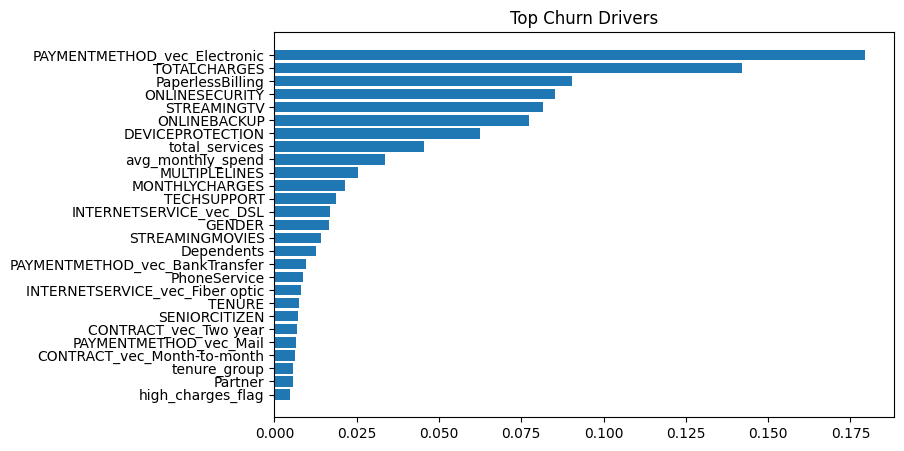

In [0]:
import matplotlib.pyplot as plt

top = importance_df.head(27)

plt.figure(figsize=(8,5))
plt.barh(top["feature"], top["importance"])
plt.gca().invert_yaxis()

plt.title("Top Churn Drivers")

plt.show()

In [0]:
#MLflow Experiment

import mlflow
import mlflow.spark

mlflow.set_experiment("/Shared/Customer_Churn_RF_Model")

<Experiment: artifact_location='dbfs:/databricks/mlflow-tracking/2683066003858061', creation_time=1772977317731, experiment_id='2683066003858061', last_update_time=1772978326496, lifecycle_stage='active', name='/Shared/Customer_Churn_RF_Model', tags={'mlflow.experiment.sourceName': '/Shared/Customer_Churn_RF_Model',
 'mlflow.experimentKind': 'custom_model_development',
 'mlflow.experimentType': 'MLFLOW_EXPERIMENT',
 'mlflow.ownerEmail': 'pasupulasunil8@gmail.com',
 'mlflow.ownerId': '78436179829002'}>

In [0]:
import mlflow

mlflow.set_experiment("/Shared/Customer_Churn_RF_Model")

with mlflow.start_run():

    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("num_trees", rf_model.getNumTrees)

    mlflow.log_metric("AUC", auc)

In [0]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import pickle

In [0]:
pdf = df_model.toPandas()
pdf.to_csv("C:/Users/PRASAD/Downloads/Customer_Churn_Predition/data/churn_final_dataset.csv", index=False)

---------------------------------------------------------------------------
OSError                                   Traceback (most recent call last)
File <command-7166873695593849>, line 2
      1 pdf = df_model.toPandas()
----> 2 pdf.to_csv("C:/Users/PRASAD/Downloads/Customer_Churn_Predition/data/churn_final_dataset.csv", index=False)

File /databricks/python/lib/python3.12/site-packages/pandas/util/_decorators.py:333, in deprecate_nonkeyword_arguments.<locals>.decorate.<locals>.wrapper(*args, **kwargs)
    327 if len(args) > num_allow_args:
    328     warnings.warn(
    329         msg.format(arguments=_format_argument_list(allow_args)),
    330         FutureWarning,
    331         stacklevel=find_stack_level(),
    332     )
--> 333 return func(*args, **kwargs)

File /databricks/python/lib/python3.12/site-packages/pandas/core/generic.py:3967, in NDFrame.to_csv(self, path_or_buf, sep, na_rep, float_format, columns, header, index, index_label, mode, encoding, compression, quotin

In [0]:
pickle.dump(rf_model, open("churn_rf_model.pkl","wb"))

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-5642498057830088>, line 1
----> 1 pickle.dump(rf_model, open("churn_rf_model.pkl","wb"))

NameError: name 'rf_model' is not defined

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-5642498057830090>, line 10
      1 from pyspark.ml.tuning import TrainValidationSplit
      3 tvs = TrainValidationSplit(
      4     estimator=rf,
      5     estimatorParamMaps=param_grid,
      6     evaluator=evaluator,
      7     trainRatio=0.8
      8 )
---> 10 tvs_model = tvs.fit(train_df)

File /databricks/python_shell/lib/dbruntime/MLWorkloadsInstrumentation/_pyspark.py:30, in _create_patch_function.<locals>.patched_method(self, *args, **kwargs)
     28 call_succeeded = False
     29 try:
---> 30     result = original_method(self, *args, **kwargs)
     31     call_succeeded = True
     32     return result

File /databricks/python/lib/python3.12/site-packages/pyspark/ml/base.py:203, in Estimator.fit(self, dataset, params)
    201         return self.copy(params)._fit(dataset)
    202     else:
--> 203         ret

+------+-------------+-------+----------+------+------------+-------------+--------------+------------+----------------+-----------+-----------+---------------+----------------+--------------+------------+-----+-------------------+-------------+-----------------+------------------+--------------+------------+-----------------+
|GENDER|SENIORCITIZEN|Partner|Dependents|TENURE|PhoneService|MULTIPLELINES|ONLINESECURITY|ONLINEBACKUP|DEVICEPROTECTION|TECHSUPPORT|STREAMINGTV|STREAMINGMOVIES|PaperlessBilling|MONTHLYCHARGES|TOTALCHARGES|Churn|INTERNETSERVICE_vec| CONTRACT_vec|PAYMENTMETHOD_vec| avg_monthly_spend|total_services|tenure_group|high_charges_flag|
+------+-------------+-------+----------+------+------------+-------------+--------------+------------+----------------+-----------+-----------+---------------+----------------+--------------+------------+-----+-------------------+-------------+-----------------+------------------+--------------+------------+-----------------+
|     0|     

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-8543607753361967>, line 31
     21 cv = CrossValidator(
     22     estimator=rf,
     23     estimatorParamMaps=param_grid,
   (...)
     27     collectSubModels=False
     28 )
     30 # Train Model
---> 31 cv_model = cv.fit(train_df)
     33 train_df.cache()
     34 train_df.count()

File /databricks/python_shell/lib/dbruntime/MLWorkloadsInstrumentation/_pyspark.py:30, in _create_patch_function.<locals>.patched_method(self, *args, **kwargs)
     28 call_succeeded = False
     29 try:
---> 30     result = original_method(self, *args, **kwargs)
     31     call_succeeded = True
     32     return result

File /databricks/python/lib/python3.12/site-packages/pyspark/ml/base.py:203, in Estimator.fit(self, dataset, params)
    201         return self.copy(params)._fit(dataset)
    202     else:
--> 203         return self._fi

---------------------------------------------------------------------------
MlflowException                           Traceback (most recent call last)
File <command-8543607753361968>, line 21
     17 mlflow.log_param("maxDepth",6)
     19 mlflow.log_metric("AUC", auc)
---> 21 mlflow.spark.log_model(model,"churn_model")
     23 print("AUC:",auc)

File /databricks/python/lib/python3.12/site-packages/mlflow/spark/__init__.py:340, in log_model(spark_model, artifact_path, conda_env, code_paths, dfs_tmpdir, sample_input, registered_model_name, signature, input_example, await_registration_for, pip_requirements, extra_pip_requirements, metadata)
    330 elif (
    331     is_local_uri(run_root_artifact_uri)
    332     or databricks_utils.is_in_databricks_serverless_runtime()
   (...)
    337     )
    338 ):
    339     dfs_tmpdir = dfs_tmpdir or MLFLOW_DFS_TMP.get()
--> 340     _check_databricks_uc_volume_tmpdir_availability(dfs_tmpdir)
    341     return Model.log(
    342         artifact